# Per-scroll eval figures (offline)

Runs the **exact `eval_int` figure** from `visualizer.py` (`_create_eval_figure_2x3`) for each of the **18 training fragments** (+ the **w055 holdout**), **one scroll per cell**. **w013 is the first cell** (most labels, most-trusted quality).

Wired for the current **`nnunet3d_lcndz`** backbone from `campaign_archs_13` (ctx 192 / ds2, attn-MIL + learned-surface + IBN).

Layout per figure (2 cols x 3 rows):

| inference | inference + inklabel overlay |
| TTA inference | TTA + inklabel overlay |
| 1.1um inklabel_raw | 2.4um inklabel_raw |

- red dashed line = the train/valid split (from each scroll's `ScrollConfig`).
- reuses the real `predict_tiles`, `_gen_tile_coords`, `_compute_tile_maps`, `_display_norm`, and `_create_eval_figure_2x3` so it matches training output byte-for-byte.
- **one scroll is loaded, rendered, then freed per cell** (gc + cuda empty_cache) so RAM never holds all at once — this is the whole point (the in-training eval crashed the box).

Set `MODEL_PATH` / `ARCH` / `CONTEXT_SIZE` / `CONTEXT_DOWNSAMPLE`, the arch flags (`ATTN_MIL` / `LEARNED_SURFACE` / `USE_IBN`), and the `MULTITILE` / `MULTITILE_SUBTILE` / `MULTITILE_GRID` triple in the CONFIG cell so the built model matches the checkpoint, then run the setup cells, then run scroll cells individually.


In [ ]:
# ============================ CONFIG — edit these ============================
# archs15 save convention is models/archs15/<tid>_final.pth. swap the tid to
# compare center-size/tile-density variants from campaign_archs_15.
MODEL_PATH = "/vesuvius/models/model_epoch_15.pth"
ARCH       = "nnunet3d_lcndz"   # current production backbone (campaign_archs_13/14/15)
TILE_SIZE  = 16      # label/output tile size
CONTEXT_SIZE = 192   # input crop centered on each tile (archs13/14/15 use 192)
CONTEXT_DOWNSAMPLE = 2   # avg-pool the ctx crop by this factor at the stem (archs13/14/15 use ds2)
DEPTH      = 24      # slices ingested at once
D_START    = 4       # depth window start
D_END      = 28      # depth window end (D_END - D_START == DEPTH)

# archs13/14/15 baseline architecture flags -- MUST match the checkpoint so the loaded
# forward path + param set line up (attn-MIL head, learned surface attn, IBN encoder).
# strict=False would otherwise SILENTLY load a different-behaving model.
ATTN_MIL        = True
LEARNED_SURFACE = True
USE_IBN         = True

# MULTITILE (campaign_archs_15 center-size/tile-density sweep) -- every archs15 checkpoint
# was trained with multitile=True, so this MUST be set (and subtile/grid MUST match the
# checkpoint) or load_state_dict(strict=False) silently drops the multitile head and
# predict_tiles falls back to single-tile (16px) output resolution -- wrong architecture,
# garbage predictions. center_px = subtile * grid. arms actually run on w013 (Sept 1-2):
#   c32_t8 (control): subtile=8  grid=4  (center=32px, 16 targets/window)
#   c16_t8:            subtile=8  grid=2  (center=16px, 4 targets/window)
#   c16_t4:            subtile=4  grid=4  (center=16px, 16 targets/window)
MULTITILE         = True
MULTITILE_SUBTILE = 8    # px per sub-tile prediction -- match the checkpoint's tid
MULTITILE_GRID    = 4    # grid side (targets/window = grid*grid) -- match the checkpoint's tid

# SPEED: prediction dominates this notebook (measured ~86-89% of wall on w013),
# and it is compute-bound on the single GPU -- there is no "predict worker" knob.
# the real levers are, in impact order:
#   1) TTA / TTA_MODE below: TTA runs the model once per view. reg map = the identity
#      view (free), so cost = #views forwards. "flips"=4x, "light"=2x, "dihedral"=6x.
#      set TTA=False for a fast preview (row 2 blank), or TTA_MODE="light" to halve it.
#   2) don't share the GPU: if a training job is running it ~halves eval throughput.
#   3) EVAL_PREFETCH: overlaps zarr reads with gpu inference (hides the read slice,
#      which is the minority of the time; biggest win on the cold first scroll).
TTA        = True      # also render the TTA-averaged map in row 2
TTA_MODE   = "light"   # "light"=id+hflip (2x) | "flips"=id+h+v+180 (4x) | "dihedral"=+/-90 too (6x)
EVAL_CMAP_NORM = "raw"   # display contrast for pred panels: "raw" | "percentile" | "rank"
EVAL_INFER_BS = 96   # 192/ds2 is VRAM-heavy; keep modest. 0 = auto (context-aware shrink)
EVAL_PREFETCH = 3     # background reader threads to overlap disk i/o w/ gpu (0 = serial)
EVAL_DPI   = 200     # saved figure dpi
OUTPUT_DIR = "output"

# the 18 training fragments (name -> zarr id) + w055 holdout. one cell per scroll below.
# w013 (PHerc1667) is FIRST -- it holds the most labels and our most-trusted quality.
EVAL_SCROLLS = {
    # non-PHerc0139 + special fragments
    "w013":        20240304141531,  # PHerc1667, split x 0.75 (largest / most-trusted labels)
    "500P2_front": 20250628074500,  # PHerc0500P2, split x 0.60
    "seg46527":    20260226000000,  # PHerc0814, split y 0.75
    "w035":        20260317000000,  # split y 0.75
    # PHerc0139 fragments
    "w044": 20260115000000,   # split y 0.8055
    "w059": 20250223000000,   # split x 0.75
    "w047": 20260206000001,   # split x 0.75
    "w056": 20260115000001,   # split y 0.50
    "w058": 20260210000000,   # split x 0.50
    "w052": 20260227000000,   # split x 0.75
    "w049": 20260318000000,   # split x 0.75
    "w046": 20260325000000,   # split x 0.60
    "w041": 20260108000000,   # split x 0.70
    "w040": 20250831000000,   # split x 0.75
    "w039": 20260302000000,   # split x 0.75
    "w038": 20260306000000,   # split x 0.75
    "w037": 20260310000000,   # split x 0.75
    "w034": 20260303000000,   # split y 0.50
    # holdout (NOT trained on) -- pure hallucination check
    "w055": 20251226000000,   # PHerc0139 holdout, not in DEFAULT_SCROLLS
}
# ============================================================================


In [2]:
import os, sys, gc, types
REPO = "/vesuvius"
if REPO not in sys.path:
    sys.path.insert(0, REPO)
os.chdir(REPO)  # so ./masks ./eroded_inklabels ./inklabels resolve

import numpy as np
import torch
import zarr
import cv2
import matplotlib.pyplot as plt

from utils.config import Config
from utils.model import create_model
# importing utils.visualizer registers the 'inferno_nan' cmap AND forces the Agg backend
from utils.visualizer import (TensorboardVisualizer as TBV, predict_tiles,
                              group_by_depth, imread_gray)
from utils.dataloader import _load_unified_cache

# visualizer forces Agg at import; restore inline so figures render in the notebook
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("torch", torch.__version__, "| cuda", torch.cuda.is_available())


2026-09-02 18:44:46.258268: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-02 18:44:46.260192: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-02 18:44:46.264229: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-02 18:44:46.275740: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1788374686.301129   27521 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788374686.30

torch 2.1.0+cu118 | cuda True


In [3]:
# ============ config, model, split + norm helpers, and the per-scroll renderer ============
def build_config():
    c = Config()
    c.data.tile_size = TILE_SIZE; c.data.depth = DEPTH
    c.data.context_size = CONTEXT_SIZE
    c.data.context_downsample = CONTEXT_DOWNSAMPLE   # archs13 runs the ctx crop at half res
    c.data.d_start = D_START; c.data.d_end = D_END
    c.data.eval_cmap_norm = EVAL_CMAP_NORM
    c.data.eval_infer_bs = EVAL_INFER_BS   # 0 = auto (context-aware); >0 = manual cap
    c.data.eval_prefetch = EVAL_PREFETCH   # background reader threads (overlap disk i/o w/ gpu)
    c.data.tta_mode = TTA_MODE             # eval TTA view set: light (2x) / flips (4x) / dihedral (6x)
    c.model.arch = ARCH
    # match the archs13 checkpoint's forward path + param set (else strict=False loads a
    # different-behaving model: wrong aggregation head, no surface attn, plain-IN encoder)
    c.model.attn_mil = ATTN_MIL
    c.model.learned_surface = LEARNED_SURFACE
    c.model.use_ibn = USE_IBN
    # campaign_archs_15 center-size/tile-density variants: MUST match the checkpoint's tid
    c.model.multitile = MULTITILE
    c.model.multitile_subtile = MULTITILE_SUBTILE
    c.model.multitile_grid = MULTITILE_GRID
    c.device = "cuda" if torch.cuda.is_available() else "cpu"
    return c

def load_model(c):
    model, n = create_model(c)
    sd = torch.load(MODEL_PATH, map_location=c.device)
    if isinstance(sd, dict) and "state_dict" in sd:
        sd = sd["state_dict"]
    missing, unexpected = model.load_state_dict(sd, strict=False)
    model.eval()
    print(f"loaded {MODEL_PATH}  params={n:,}  missing={len(missing)} unexpected={len(unexpected)}")
    return model

def _scroll_cfg(sid, c):
    for s in c.data.scrolls:
        if int(s.scroll_id) == int(sid):
            return s
    return None

def _splits(sid, H, W, c):
    """replicate DataManager's tile-snapped train/valid split so the red divider + the
    predicted extent match training exactly. returns (full_y, full_x, train_split_n, axis)."""
    T = c.data.tile_size
    sc = _scroll_cfg(sid, c)
    cxf = sc.crop_x_frac if sc else (0.0, 1.0)
    cyf = sc.crop_y_frac if sc else (0.0, 1.0)
    axis = (sc.split_axis if sc else "x").lower()
    frac = sc.train_split_frac if sc else 0.75
    x0 = (int(W * cxf[0]) // T) * T; x1 = (int(W * cxf[1]) // T) * T
    y0 = (int(H * cyf[0]) // T) * T; y1 = (int(H * cyf[1]) // T) * T
    x1 = max(x1, x0 + T); y1 = max(y1, y0 + T)
    if axis == "y":
        split = (int((y1 - y0) * frac) // T) * T
        train_range = (y0, y0 + split); valid_range = (y0 + split, y1)
        full_y = (train_range[0], valid_range[1]); full_x = (x0, x1)
    else:
        split = (int((x1 - x0) * frac) // T) * T
        train_range = (x0, x0 + split); valid_range = (x0 + split, x1)
        full_y = (y0, y1); full_x = (train_range[0], valid_range[1])
    return full_y, full_x, (train_range[1] - train_range[0]) // T, axis

def get_norm(sid, vol, mask):
    """cached norm for training scrolls; memory-bounded fallback if uncached."""
    st = _load_unified_cache().get(str(sid))
    if st and all(k in st for k in ("mean", "std", "min", "max")):
        return st["mean"], st["std"], st["min"], st["max"]
    print(f"[norm] computing for {sid} (uncached)...")
    s = s2 = cnt = 0.0
    for d in range(int(vol.shape[0])):
        v = np.asarray(vol[d]).astype(np.float64)[mask > 0]
        if v.size:
            s += v.sum(); s2 += (v * v).sum(); cnt += v.size
    mean = s / max(cnt, 1); std = float(np.sqrt(max(s2 / max(cnt, 1) - mean * mean, 1e-12)))
    gmin = gmax = None
    for d in range(int(vol.shape[0])):
        v = (np.asarray(vol[d]).astype(np.float64)[mask > 0] - mean) / std
        if v.size:
            gmin = v.min() if gmin is None else min(gmin, v.min())
            gmax = v.max() if gmax is None else max(gmax, v.max())
    return mean, std, float(gmin), float(gmax)

def _run_name():
    base = MODEL_PATH.replace("\\", "/").rstrip("/").split("/")[-1]
    return base.replace("_final.pth", "").replace(".pth", "") or "run"

def render_eval(name, sid, model, c):
    """load ONE scroll, run the exact eval_int figure, save + preview, then free RAM."""
    sid = int(sid)
    # a minimal stand-in 'self' so we can call the real visualizer methods unchanged
    fake = types.SimpleNamespace(c=c)
    fake._display_norm = types.MethodType(TBV._display_norm, fake)

    vol = zarr.open(os.path.join(c.data.zarr_path, f"{sid}.zarr"), mode="r")
    H, W = int(vol.shape[1]), int(vol.shape[2])
    mask = (imread_gray(f"masks/{sid}.png") > 127).astype(np.uint8)
    labels = (imread_gray(f"eroded_inklabels/{sid}.png") > 127).astype(np.uint8)
    gm, gs, gmin, gmax = get_norm(sid, vol, mask)

    full_y, full_x, train_split_n, split_axis = _splits(sid, H, W, c)
    z_range = (c.data.d_start, c.data.d_end)
    coords = TBV._gen_tile_coords(fake, z_range, full_y, full_x, mask, z_step=c.data.depth)
    grouped = group_by_depth(coords)
    d_off = sorted(grouped)[0]                       # primary depth block (eval uses the first)

    # single read -> raw + TTA maps (TTA re-augments the loaded tiles, no re-read)
    if TTA:
        reg_pred, tta_pred = predict_tiles(c, model, vol, mask, grouped[d_off], full_y, full_x,
                                           c.data.d_start + d_off, f"eval_{sid}",
                                           gm, gs, gmin, gmax, also_tta=True)
    else:
        reg_pred = predict_tiles(c, model, vol, mask, grouped[d_off], full_y, full_x,
                                 c.data.d_start + d_off, f"eval_{sid}", gm, gs, gmin, gmax)
        tta_pred = None

    label_binary, _, _ = TBV._compute_tile_maps(fake, labels, mask, full_y, full_x)

    # raw inklabel panels: crop to the eval extent, then RESIZE to the prediction map's tile
    # dimensions (matches visualizer.py's _raw_ink exactly). without this resize the raw crop
    # stays at native 1.1um/2.4um scan resolution -- a totally different pixel grid from the
    # tile/sub-tile-resolution prediction maps -- so the panel renders at the wrong size/aspect.
    mh, mw = mask.shape[:2]
    pred_h, pred_w = reg_pred.shape
    def _raw(sub):
        img = imread_gray(f"./inklabels/{sub}/{sid}.png")
        if img is None:
            return None
        rh, rw = img.shape[:2]
        ry0 = int(full_y[0] * rh / max(mh, 1)); ry1 = int(full_y[1] * rh / max(mh, 1))
        rx0 = int(full_x[0] * rw / max(mw, 1)); rx1 = int(full_x[1] * rw / max(mw, 1))
        crop = img[ry0:ry1, rx0:rx1]
        if crop.size == 0:
            return None
        return cv2.resize(crop, (pred_w, pred_h), interpolation=cv2.INTER_LINEAR)
    raw_1_1, raw_2_4 = _raw("1_1um"), _raw("2_4um")

    fig = TBV._create_eval_figure_2x3(fake, reg_pred, tta_pred, label_binary,
                                      raw_1_1, raw_2_4, train_split_n, split_axis)
    fig.suptitle(f"{name}  (scroll {sid})  {split_axis}-split", fontsize=10)

    out_dir = os.path.join(OUTPUT_DIR, "eval_visualizations", _run_name())
    os.makedirs(out_dir, exist_ok=True)
    out_p = os.path.join(out_dir, f"{name}_{sid}.png")
    fig.savefig(out_p, dpi=EVAL_DPI, bbox_inches="tight")
    print(f"[saved] {out_p}  pred grid {reg_pred.shape}  extent y{full_y} x{full_x}")
    plt.close(fig)

    # show resized to 1/8 to save notebook space
    from PIL import Image
    from IPython.display import display
    img = Image.open(out_p)
    r_method = getattr(Image, "Resampling", Image).LANCZOS if hasattr(Image, "Resampling") else getattr(Image, "ANTIALIAS", 1)
    img_low = img.resize((img.width // 8, img.height // 8), resample=r_method)
    display(img_low)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # free everything so the next cell starts clean (the whole reason for per-cell rendering)
    del vol, mask, labels, reg_pred, tta_pred, label_binary, raw_1_1, raw_2_4, fig
    gc.collect()


In [4]:
# build config + load the model ONCE (reused by every scroll cell below)
C = build_config()
MODEL = load_model(C)
print("arch:", ARCH, "| context:", CONTEXT_SIZE, "ds", CONTEXT_DOWNSAMPLE,
      "| attn_mil:", ATTN_MIL, "learned_surface:", LEARNED_SURFACE, "ibn:", USE_IBN,
      "| cmap_norm:", EVAL_CMAP_NORM)


Model parameters (nnunet3d_lcndz): 5,603,189
loaded /vesuvius/models/model_epoch_15.pth  params=5,603,189  missing=0 unexpected=4
arch: nnunet3d_lcndz | context: 192 ds 2 | attn_mil: True learned_surface: True ibn: True | cmap_norm: raw


In [ ]:
# w013 — PHerc1667, split x 0.75  (FIRST: most labels, most-trusted quality)
render_eval("w013", EVAL_SCROLLS["w013"], MODEL, C)


[predict] reading 178390 tiles in 640 row-strips (eval_20240304141531)


Read eval_20240304141531:   3%|▎         | 20/640 [00:01<01:09,  8.88it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 1.69 GiB. GPU 0 has a total capacty of 23.55 GiB of which 548.19 MiB is free. Process 7420 has 16.81 GiB memory in use. Including non-PyTorch memory, this process has 6.19 GiB memory in use. Of the allocated memory 3.70 GiB is allocated by PyTorch, and 2.24 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

Read eval_20240304141531:   3%|▎         | 21/640 [00:19<01:09,  8.88it/s]

[predict] reading 49876 tiles in 333 row-strips (eval_20250628074500)


[predict] eval_20250628074500 done in 841.2s  predict 773.6s (92.0%)  read/wait  67.6s ( 8.0%)  [prefetch x3]
[saved] output/eval_visualizations/model_epoch_20/500P2_front_20250628074500.png  pred grid (392, 223)  extent y(0, 6272) x(0, 3568)


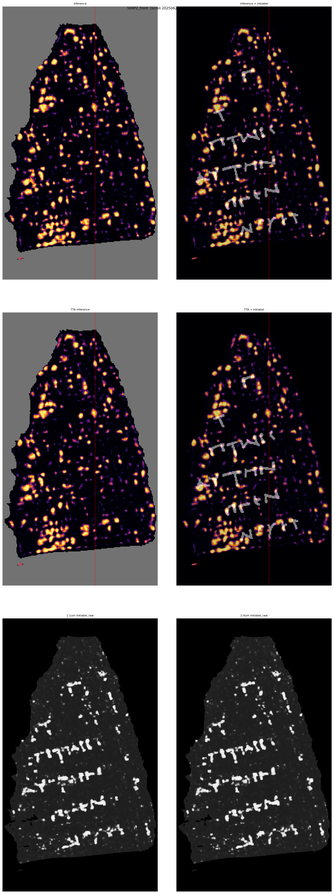

In [5]:
# 500P2_front — PHerc0500P2, split x 0.60
render_eval("500P2_front", EVAL_SCROLLS["500P2_front"], MODEL, C)


In [ ]:
# w035 — split y 0.75
render_eval("w035", EVAL_SCROLLS["w035"], MODEL, C)


In [ ]:
# w055 — PHerc0139 HOLDOUT (not trained on); pure hallucination check
render_eval("w055", EVAL_SCROLLS["w055"], MODEL, C)


In [5]:
# w044 — split y 0.8055
render_eval("w044", EVAL_SCROLLS["w044"], MODEL, C)


[predict] reading 169682 tiles in 371 row-strips (eval_20260115000000)


Read eval_20260115000000:   3%|▎         | 12/371 [00:04<04:35,  1.30it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 3.38 GiB. GPU 0 has a total capacty of 19.58 GiB of which 3.28 GiB is free. Process 769837 has 8.45 GiB memory in use. Including non-PyTorch memory, this process has 7.85 GiB memory in use. Of the allocated memory 5.38 GiB is allocated by PyTorch, and 2.24 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [ ]:
# w059 — split x 0.75
render_eval("w059", EVAL_SCROLLS["w059"], MODEL, C)


In [ ]:
# w047 — split x 0.75
render_eval("w047", EVAL_SCROLLS["w047"], MODEL, C)


In [ ]:
# w056 — split y 0.50
render_eval("w056", EVAL_SCROLLS["w056"], MODEL, C)


In [ ]:
# w058 — split x 0.75
render_eval("w058", EVAL_SCROLLS["w058"], MODEL, C)


In [ ]:
# w052 — split x 0.75
render_eval("w052", EVAL_SCROLLS["w052"], MODEL, C)


In [ ]:
# w049 — split x 0.75
render_eval("w049", EVAL_SCROLLS["w049"], MODEL, C)


In [ ]:
# w046 — split x 0.75
render_eval("w046", EVAL_SCROLLS["w046"], MODEL, C)


In [ ]:
# w041 — split x 0.75
render_eval("w041", EVAL_SCROLLS["w041"], MODEL, C)


In [ ]:
# w040 — split x 0.75
render_eval("w040", EVAL_SCROLLS["w040"], MODEL, C)


In [ ]:
# w039 — split x 0.75
render_eval("w039", EVAL_SCROLLS["w039"], MODEL, C)


In [ ]:
# w038 — split x 0.75
render_eval("w038", EVAL_SCROLLS["w038"], MODEL, C)


In [ ]:
# w037 — split x 0.75
render_eval("w037", EVAL_SCROLLS["w037"], MODEL, C)


In [ ]:
# w034 — split x 0.75
render_eval("w034", EVAL_SCROLLS["w034"], MODEL, C)


In [ ]:
# seg46527 — PHerc0814, split y 0.75
render_eval("seg46527", EVAL_SCROLLS["seg46527"], MODEL, C)
